# **Loading Libraries**

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import os
import random

from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

# **Loading Dataset**

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

train_dir = path + '/Training'
test_dir = path + '/Testing'

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [4]:
folders = [f for f in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, f))]
print("Number of folders in train_dir:", len(folders))
print("Folder names:", folders)

Number of folders in train_dir: 4
Folder names: ['pituitary', 'notumor', 'meningioma', 'glioma']


In [5]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

In [6]:
def load_dataset(dir,batch_size, img_size):
  dataset = image_dataset_from_directory(
        dir,
        shuffle=True,
        image_size=img_size,
        batch_size=batch_size
    )
  return dataset

In [7]:
train_dataset = load_dataset(train_dir, BATCH_SIZE, (IMAGE_SIZE, IMAGE_SIZE))

Found 5712 files belonging to 4 classes.


In [8]:
test_dataset = load_dataset(test_dir, BATCH_SIZE, (IMAGE_SIZE, IMAGE_SIZE))

Found 1311 files belonging to 4 classes.


In [9]:
train_dataset.class_names

['glioma', 'meningioma', 'notumor', 'pituitary']

# **Data Visualization**

<Figure size 1000x1000 with 0 Axes>

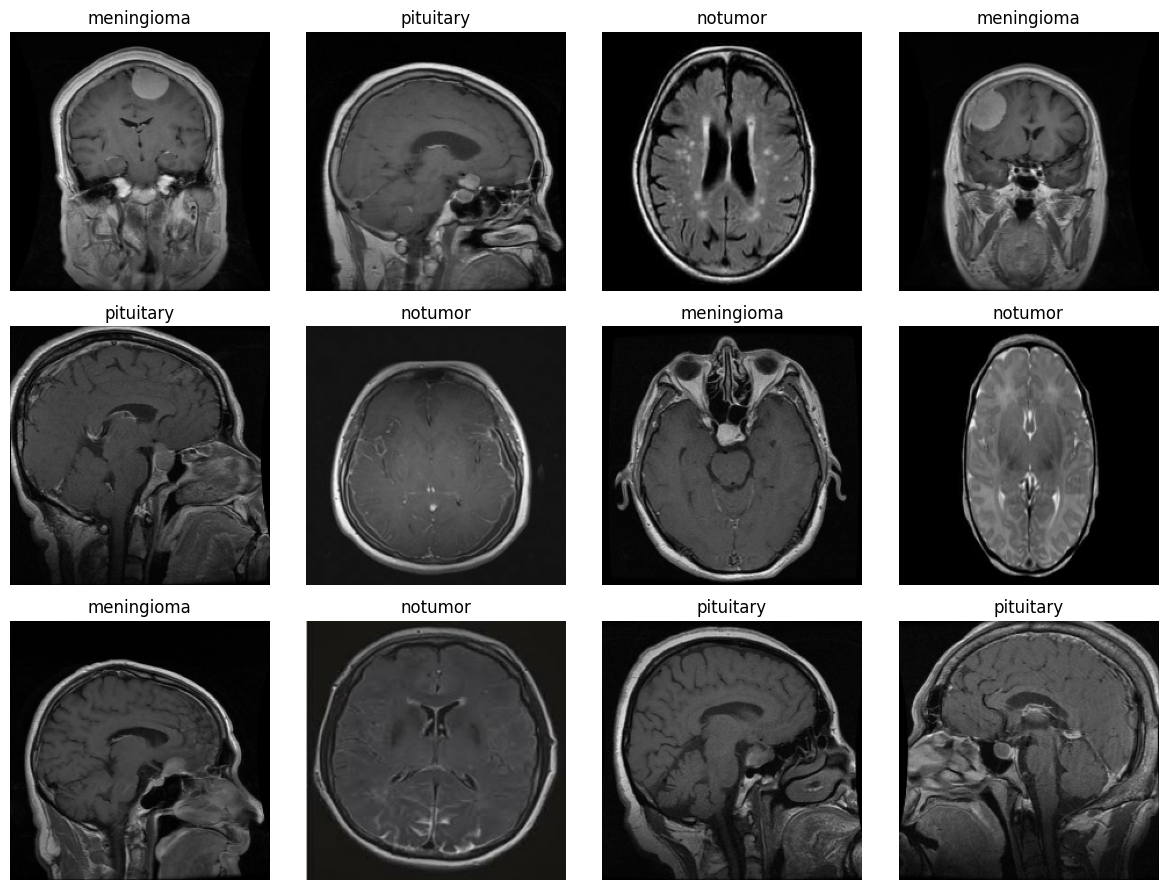

In [10]:
def plot_images(dataset, num_images=12):
    class_names = dataset.class_names
    plt.figure(figsize=(10, 10))

    for images, labels in dataset.take(1):
        images, labels = images.numpy() / 255.0, labels.numpy()
        fig, axes = plt.subplots(3, 4, figsize=(12, 9))
        axes = axes.ravel()

        for i in range(num_images):
            axes[i].imshow(images[i])
            axes[i].set_title(class_names[labels[i]])
            axes[i].axis("off")

        plt.tight_layout()
        plt.show()
        break

plot_images(train_dataset)

# **Applying Data Augmentation**

In [11]:
def augmented_data(dataset):
    augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomBrightness(0.2),
        tf.keras.layers.RandomContrast(0.2),
        tf.keras.layers.Rescaling(1./255)
    ])

    return dataset.map(lambda x, y: (augmentation(x, training=True), y))

In [12]:
aug_train = augmented_data(train_dataset)

In [13]:
aug_test = augmented_data(test_dataset)

In [14]:
augmented_img = aug_train.take(2).as_numpy_iterator().next()

In [15]:
augmented_img[0][5].max()

np.float32(1.0)

# **Plotting Augmented Images**

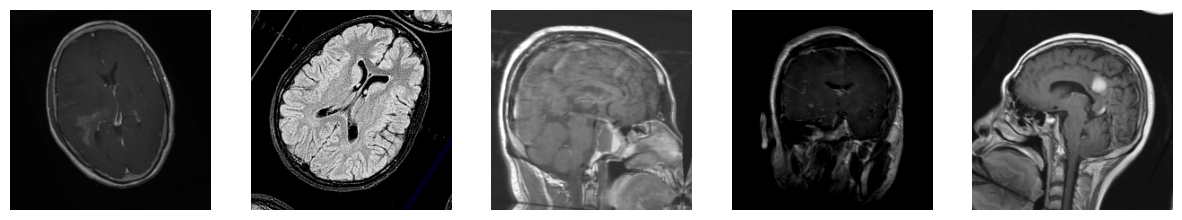

In [16]:
num_images = 5
fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

for i in range(num_images):
    image = augmented_img[0][i]
    axes[i].imshow(image)
    axes[i].axis('off')

plt.show()

# **Splitting Test DataSet Into Validation**

In [17]:
total_batches = tf.data.experimental.cardinality(aug_test).numpy()

val_batches = int(0.8 * total_batches)

aug_val = aug_test.take(val_batches)
aug_test = aug_test.skip(val_batches)

print(f"Validation Set Batches: {tf.data.experimental.cardinality(aug_val).numpy()}")
print(f"Test Set Batches: {tf.data.experimental.cardinality(aug_test).numpy()}")

Validation Set Batches: 32
Test Set Batches: 9


# **Model Building**

**Using VGG16**

In [18]:
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
for layer in base_model.layers:
    layer.trainable = False

In [20]:
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

**Fine Tunning**

In [21]:
model = Sequential()
model.add(layers.Input(shape = (IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.BatchNormalization())
model.add(layers.Dense(256, activation = 'relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(128, activation = 'relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))
model.add(layers.Dense(len(train_dataset.class_names), activation = 'softmax'))

In [22]:
model.compile(
    optimizer = Adam(learning_rate=0.0005),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['sparse_categorical_accuracy']
)

In [23]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,881,988 (56.77 MB)

 Trainable params: 7,245,444 (27.64 MB)

 Non-trainable params: 7,636,544 (29.13 MB)

In [24]:
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

In [26]:
history = model.fit(
    aug_train,
    validation_data=aug_val,
    epochs=1,
    callbacks=[lr_scheduler]
)

179/179 ━━━━━━━━━━━━━━━━━━━━ 4842s 27s/step - loss: 0.6749 - sparse_categorical_accuracy: 0.7612 - val_loss: 3.1808 - val_sparse_categorical_accuracy: 0.5146 - learning_rate: 5.0000e-04


# **Visualizing Results**

**Plots Train vs Validation**

**Accuracy Plot**

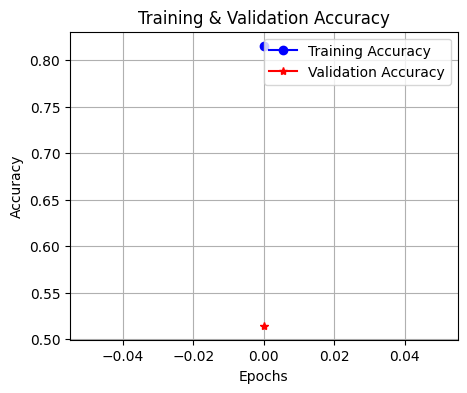

In [27]:
train_acc = history.history['sparse_categorical_accuracy']
val_acc = history.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(5, 4))
plt.plot(train_acc, 'bo-', label="Training Accuracy")
plt.plot(val_acc, 'r*-', label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

**Loss Plot**

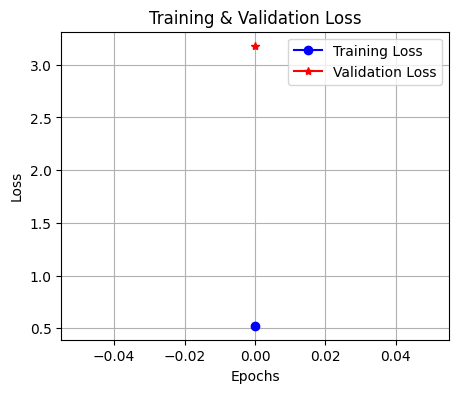

In [28]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']


plt.figure(figsize=(5, 4))
plt.plot(train_loss, 'bo-', label="Training Loss")
plt.plot(val_loss, 'r*-', label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# **Predicting Result Using Test Dataset**

**Classification Report**

In [29]:
y_true = []
y_pred = []

for images, labels in aug_test:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=train_dataset.class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step
              precision    recall  f1-score   support

      glioma       0.38      1.00      0.55        71
  meningioma       1.00      0.04      0.08        69
     notumor       1.00      0.49      0.66        87
   pituitary       0.59      0.53      0.56        60

    accuracy                           0.52       287
   macro avg       0.74      0.52      0.46       287
weighted avg       0.76      0.52      0.47       287



# **Confussion Matrix**

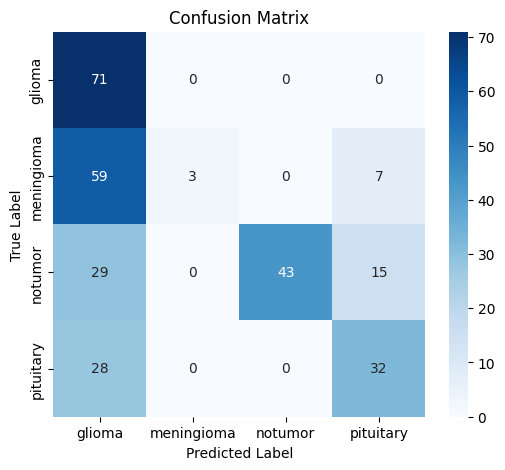

In [30]:
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_dataset.class_names,
            yticklabels=train_dataset.class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()